# Week 1 — EDA & Preprocessing
KuaiRec short video recommendation dataset.


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
DATA_DIR = Path('../datasets/KuaiRec 2.0/data')

## 1. Load Data

In [2]:
big   = pd.read_csv(DATA_DIR / 'big_matrix.csv')
small = pd.read_csv(DATA_DIR / 'small_matrix.csv')
print(f'big_matrix:   {big.shape}   users={big.user_id.nunique():,}  videos={big.video_id.nunique():,}')
print(f'small_matrix: {small.shape}  users={small.user_id.nunique():,}  videos={small.video_id.nunique():,}')
big.head(3)

big_matrix:   (12530806, 8)   users=7,176  videos=10,728
small_matrix: (4676570, 8)  users=1,411  videos=3,327


,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio
0,0,3649,13838,10867,2020-07-05 00:08:23.438,20200705,1.593879e+09,1.273397
1,0,9598,13665,10984,2020-07-05 00:13:41.297,20200705,1.593879e+09,1.244082
2,0,5262,851,7908,2020-07-05 00:16:06.687,20200705,1.593879e+09,0.107613


In [3]:
# Binary label
big['label']   = (big['watch_ratio']   > 2.0).astype(int)
small['label'] = (small['watch_ratio'] > 2.0).astype(int)
print(f'big_matrix   positive rate: {big.label.mean():.3f}')
print(f'small_matrix positive rate: {small.label.mean():.3f}')

big_matrix   positive rate: 0.075
small_matrix positive rate: 0.046


## 2. Watch Ratio Distribution

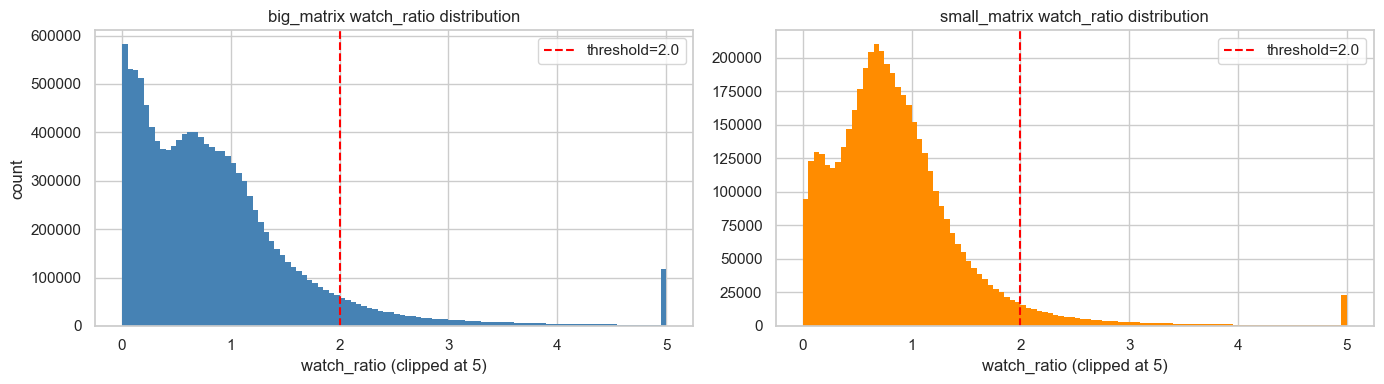


big_matrix watch_ratio stats:
count    1.253081e+07
mean     9.445059e-01
std      1.674601e+00
min      0.000000e+00
25%      3.148246e-01
50%      7.234710e-01
75%      1.177644e+00
max      5.734571e+02
Name: watch_ratio, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Clip at 5 for readability
wr_clip = big['watch_ratio'].clip(0, 5)
axes[0].hist(wr_clip, bins=100, color='steelblue', edgecolor='none')
axes[0].axvline(2.0, color='red', linestyle='--', label='threshold=2.0')
axes[0].set_xlabel('watch_ratio (clipped at 5)')
axes[0].set_ylabel('count')
axes[0].set_title('big_matrix watch_ratio distribution')
axes[0].legend()

wr_small = small['watch_ratio'].clip(0, 5)
axes[1].hist(wr_small, bins=100, color='darkorange', edgecolor='none')
axes[1].axvline(2.0, color='red', linestyle='--', label='threshold=2.0')
axes[1].set_xlabel('watch_ratio (clipped at 5)')
axes[1].set_title('small_matrix watch_ratio distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('../experiments/eda_watch_ratio.png', bbox_inches='tight')
plt.show()

print('\nbig_matrix watch_ratio stats:')
print(big['watch_ratio'].describe())

## 2b. Video Duration Distribution

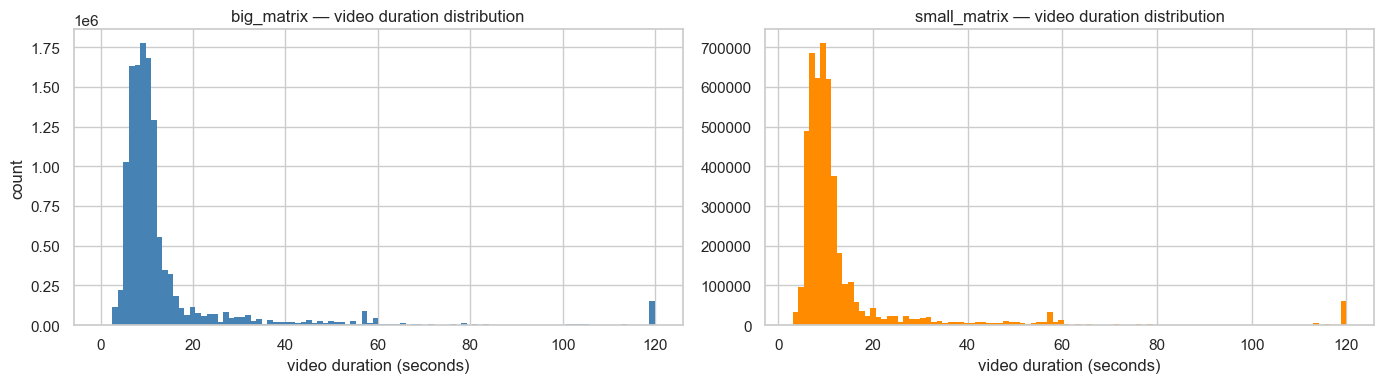


big_matrix video_duration (seconds) stats:
count    1.253081e+07
mean     1.462157e+01
std      1.983474e+01
min      1.400000e-01
25%      7.434000e+00
50%      9.636000e+00
75%      1.217900e+01
max      3.150720e+02
Name: video_duration_sec, dtype: float64

small_matrix video_duration (seconds) stats:
count    4.676570e+06
mean     1.448645e+01
std      2.046711e+01
min      3.067000e+00
25%      7.523000e+00
50%      9.600000e+00
75%      1.193400e+01
max      3.150720e+02
Name: video_duration_sec, dtype: float64


In [5]:
# video_duration is in milliseconds — convert to seconds
big['video_duration_sec'] = big['video_duration'] / 1000
small['video_duration_sec'] = small['video_duration'] / 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(big['video_duration_sec'].clip(0, 120), bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('video duration (seconds)')
axes[0].set_ylabel('count')
axes[0].set_title('big_matrix — video duration distribution')

axes[1].hist(small['video_duration_sec'].clip(0, 120), bins=100, color='darkorange', edgecolor='none')
axes[1].set_xlabel('video duration (seconds)')
axes[1].set_title('small_matrix — video duration distribution')

plt.tight_layout()
plt.savefig('../experiments/eda_video_duration.png', bbox_inches='tight')
plt.show()

print('\nbig_matrix video_duration (seconds) stats:')
print(big['video_duration_sec'].describe())
print(f'\nsmall_matrix video_duration (seconds) stats:')
print(small['video_duration_sec'].describe())

## 3. User Activity Distribution

Interactions per user — mean: 1746  median: 1846  min: 100  max: 16015


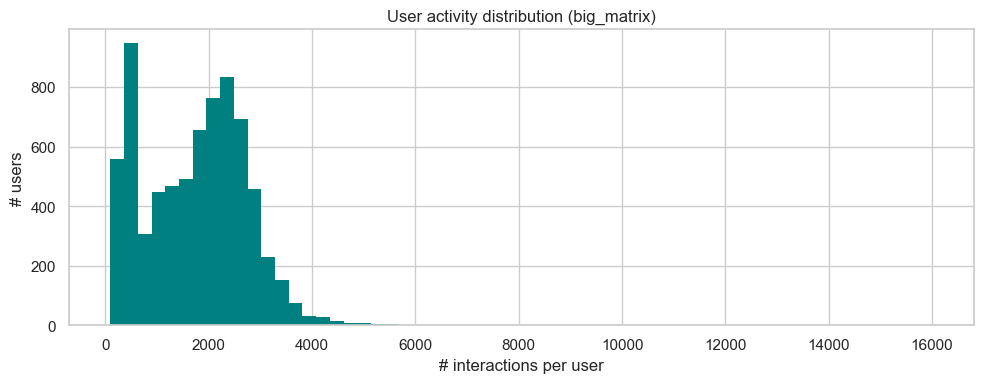

In [6]:
user_counts = big.groupby('user_id').size()
print(f'Interactions per user — mean: {user_counts.mean():.0f}  median: {user_counts.median():.0f}  min: {user_counts.min()}  max: {user_counts.max()}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(user_counts, bins=60, color='teal', edgecolor='none')
ax.set_xlabel('# interactions per user')
ax.set_ylabel('# users')
ax.set_title('User activity distribution (big_matrix)')
plt.tight_layout()
plt.savefig('../experiments/eda_user_activity.png', bbox_inches='tight')
plt.show()

## 4. Video Popularity (Long Tail)

Interactions per video — mean: 1168  median: 243  min: 1  max: 27615


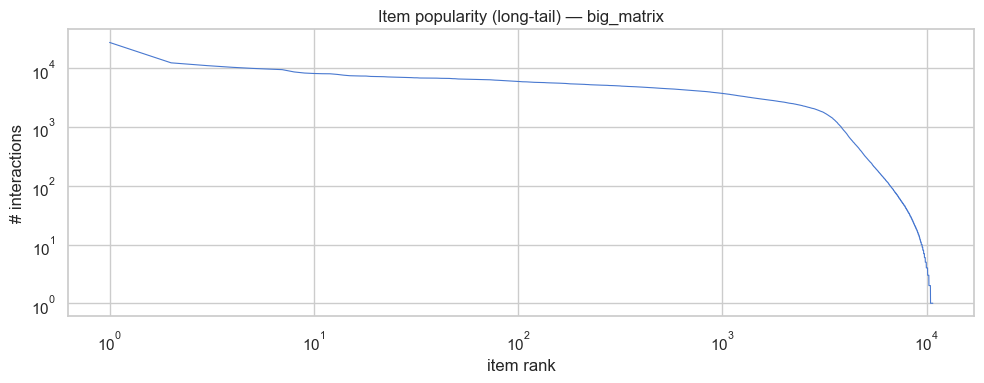

In [7]:
item_counts = big.groupby('video_id').size().sort_values(ascending=False)
print(f'Interactions per video — mean: {item_counts.mean():.0f}  median: {item_counts.median():.0f}  min: {item_counts.min()}  max: {item_counts.max()}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(1, len(item_counts)+1), item_counts.values, linewidth=0.8)
ax.set_xlabel('item rank')
ax.set_ylabel('# interactions')
ax.set_title('Item popularity (long-tail) — big_matrix')
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('../experiments/eda_item_popularity.png', bbox_inches='tight')
plt.show()

## 5. Temporal Coverage

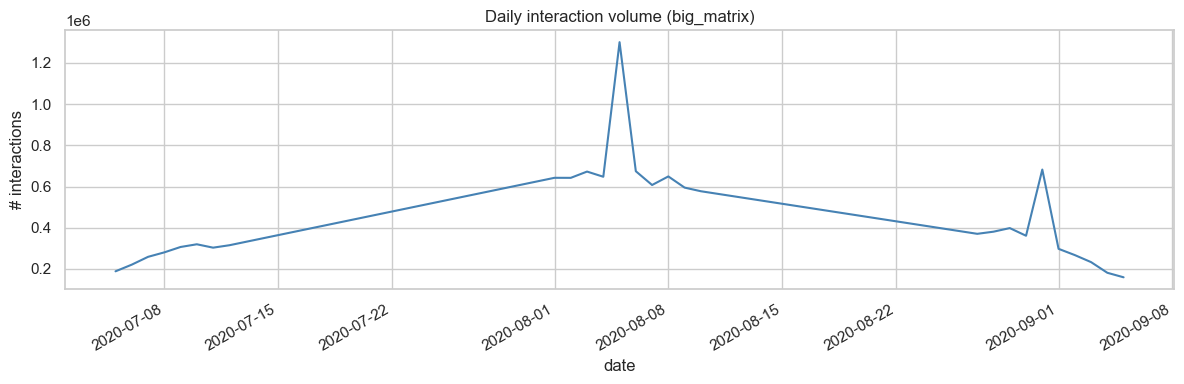

Date range: 2020-07-05 00:00:00 → 2020-09-05 00:00:00


In [8]:
big['date_dt'] = pd.to_datetime(big['date'], format='%Y%m%d')
daily = big.groupby('date_dt').size()

fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax, color='steelblue')
ax.set_xlabel('date')
ax.set_ylabel('# interactions')
ax.set_title('Daily interaction volume (big_matrix)')
plt.tight_layout()
plt.savefig('../experiments/eda_temporal.png', bbox_inches='tight')
plt.show()

print(f'Date range: {daily.index.min()} → {daily.index.max()}')

## 6. Chronological Train / Val / Test Split

In [9]:
from src.data.preprocessing import split_big_matrix, load_big_matrix

big_full = load_big_matrix()
train, val, test = split_big_matrix(big_full)

print(f'train → {train.timestamp.min():.0f} to {train.timestamp.max():.0f}')
print(f'val   → {val.timestamp.min():.0f} to {val.timestamp.max():.0f}')
print(f'test  → {test.timestamp.min():.0f} to {test.timestamp.max():.0f}')

# Overlap check
print(f'\ntrain users: {train.user_id.nunique():,}   train items: {train.video_id.nunique():,}')
print(f'val   users: {val.user_id.nunique():,}     val   items: {val.video_id.nunique():,}')
print(f'test  users: {test.user_id.nunique():,}    test  items: {test.video_id.nunique():,}')

Split sizes  train: 8,771,564  val: 1,879,621  test: 1,879,621
train → 1592872451 to 1597015523
val   → 1597015524 to 1598783760
test  → 1598783760 to 1599694332

train users: 7,174   train items: 7,896
val   users: 7,094     val   items: 5,431
test  users: 6,911    test  items: 5,246


## 7. Sequence Statistics

Sequences built for 7,174 users (threshold=0.5, total interactions=5,685,497)
Sequence length — mean: 793  median: 730  max: 3601


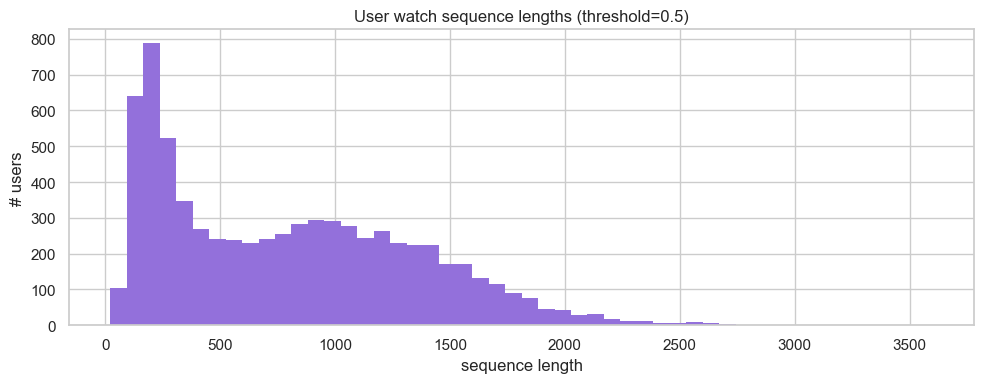

In [10]:
from src.data.preprocessing import build_watch_sequences

sequences = build_watch_sequences(train, threshold=0.5)
seq_lengths = [len(s) for s in sequences.values()]

print(f'Sequence length — mean: {np.mean(seq_lengths):.0f}  median: {np.median(seq_lengths):.0f}  max: {max(seq_lengths)}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seq_lengths, bins=50, color='mediumpurple', edgecolor='none')
ax.set_xlabel('sequence length')
ax.set_ylabel('# users')
ax.set_title('User watch sequence lengths (threshold=0.5)')
plt.tight_layout()
plt.savefig('../experiments/eda_sequence_lengths.png', bbox_inches='tight')
plt.show()

## 8. Category Distribution

C:\Users\Zbook G3\AppData\Local\Temp\ipykernel_24120\2482673103.py:10: UserWarning: Glyph 27665 (\N{CJK UNIFIED IDEOGRAPH-6C11}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Zbook G3\AppData\Local\Temp\ipykernel_24120\2482673103.py:10: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Zbook G3\AppData\Local\Temp\ipykernel_24120\2482673103.py:10: UserWarning: Glyph 36164 (\N{CJK UNIFIED IDEOGRAPH-8D44}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Zbook G3\AppData\Local\Temp\ipykernel_24120\2482673103.py:10: UserWarning: Glyph 35759 (\N{CJK UNIFIED IDEOGRAPH-8BAF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Zbook G3\AppData\Local\Temp\ipykernel_24120\2482673103.py:10: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Zbook G3\AppData\Local\Temp\ipykernel_24120\2482673103.py:10: UserWarning: Glyph 23578 (\N{CJK UNIFIE

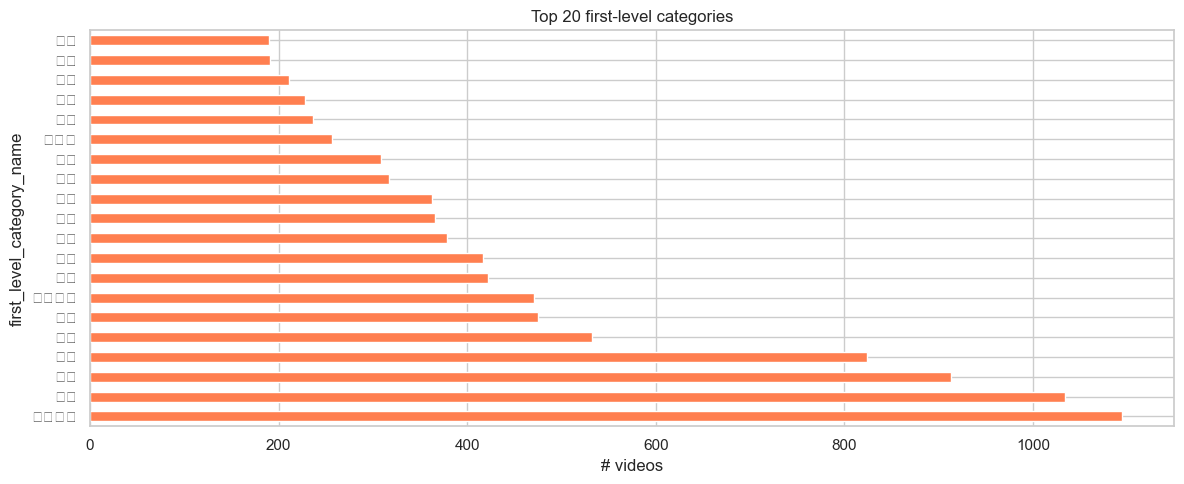

In [11]:
from src.data.preprocessing import load_caption_category

cat_df = load_caption_category()
top_cats = cat_df['first_level_category_name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 5))
top_cats.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('# videos')
ax.set_title('Top 20 first-level categories')
plt.tight_layout()
plt.savefig('../experiments/eda_categories.png', bbox_inches='tight')
plt.show()

## 9. Summary

In [12]:
summary = {
    'big_matrix rows': len(big),
    'big_matrix users': big.user_id.nunique(),
    'big_matrix videos': big.video_id.nunique(),
    'small_matrix rows': len(small),
    'small_matrix users': small.user_id.nunique(),
    'small_matrix videos': small.video_id.nunique(),
    'positive rate (big, thr=2.0)': round(big.label.mean(), 4),
    'positive rate (small, thr=2.0)': round(small.label.mean(), 4),
    'train size': len(train),
    'val size': len(val),
    'test size': len(test),
    'mean seq len (thr=0.5)': round(np.mean(seq_lengths), 1),
}
for k, v in summary.items():
    print(f'{k:<45} {v:>12,}' if isinstance(v, int) else f'{k:<45} {v}')

big_matrix rows                                 12,530,806
big_matrix users                                     7,176
big_matrix videos                                   10,728
small_matrix rows                                4,676,570
small_matrix users                                   1,411
small_matrix videos                                  3,327
positive rate (big, thr=2.0)                  0.0747
positive rate (small, thr=2.0)                0.0464
train size                                       8,771,564
val size                                         1,879,621
test size                                        1,879,621
mean seq len (thr=0.5)                        792.5
